    V1 gran  V1 Slough  V1 Hyper  V2 gran  V2 Slough  V2 Hyper  V3 gran  \
0       100          0         0       75         25         0       25   
1         0        100         0      100          0         0      100   
2        45         55         0       27         73         0       38   
3         0          0       100        0          0       100      100   
4       100          0         0      100          0         0      100   
5       100          0         0      100          0         0      100   
6       100          0         0      100          0         0      100   
7       100          0         0      100          0         0      100   
8       100          0         0      100          0         0      100   
9       100          0         0      100          0         0      100   
10      100          0         0      100          0         0        0   
11      100          0         0      100          0         0      100   
12      100          0   

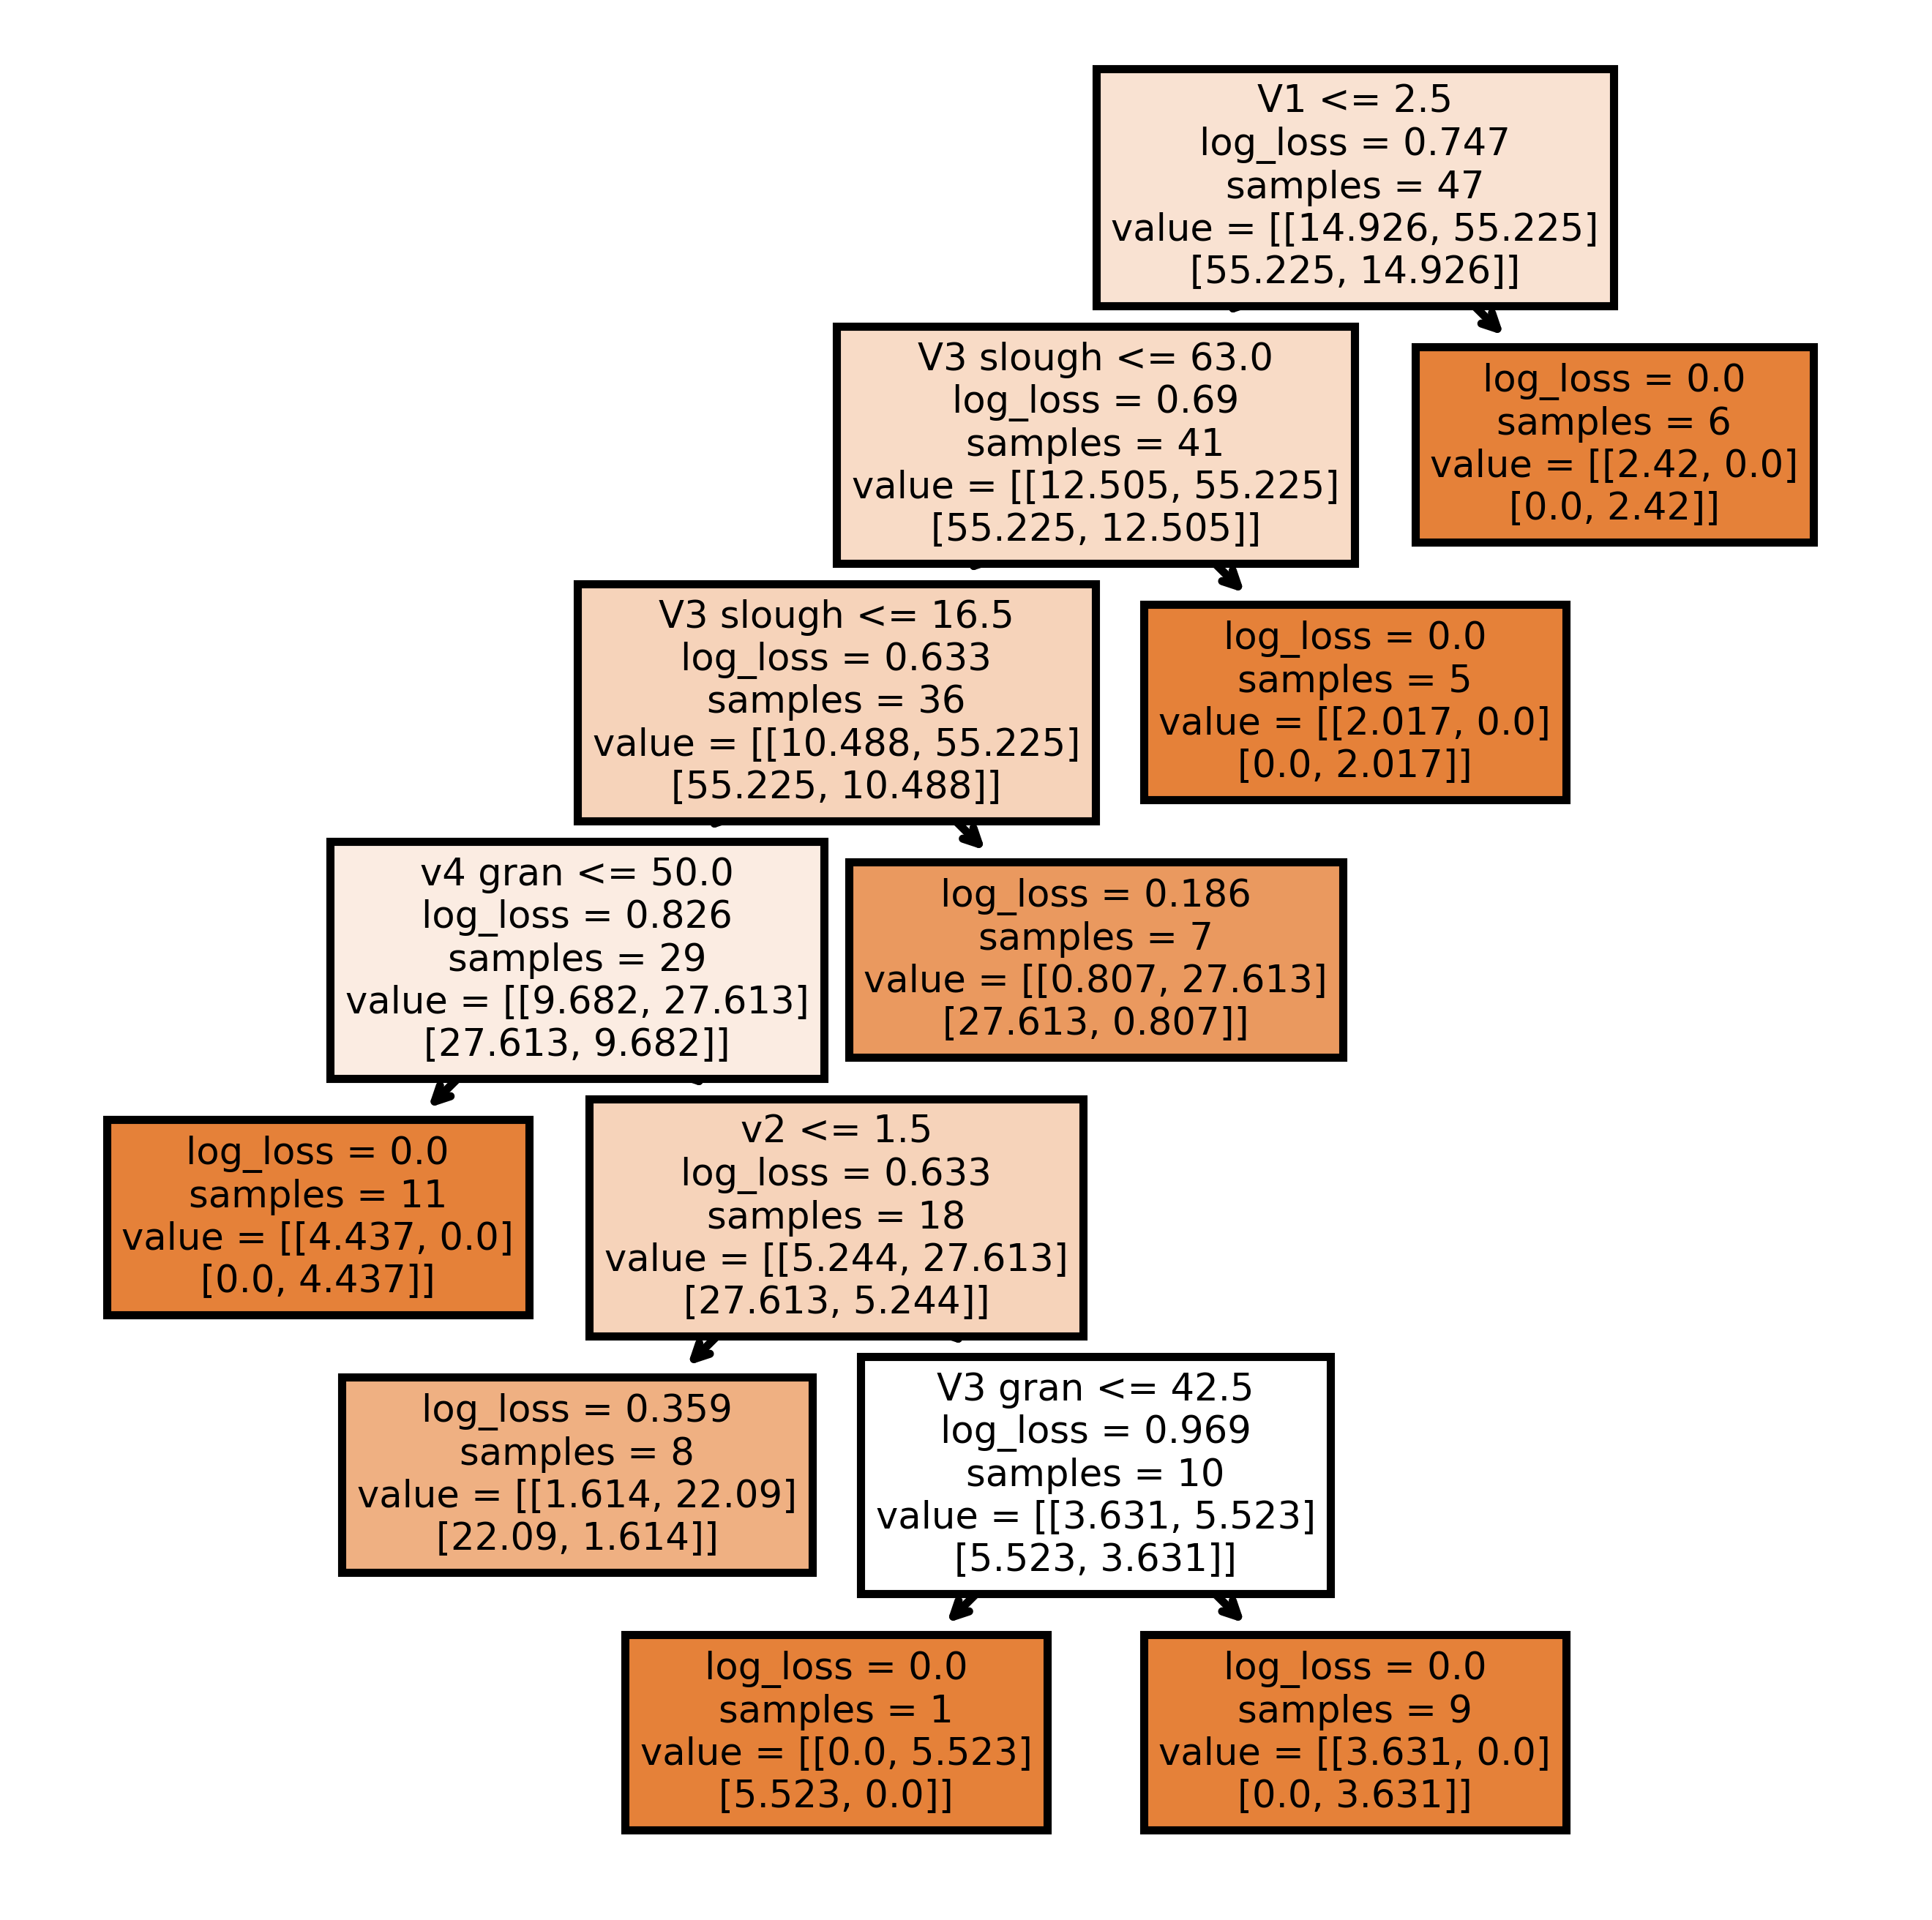

Accuracy: 73.33333333333333 %


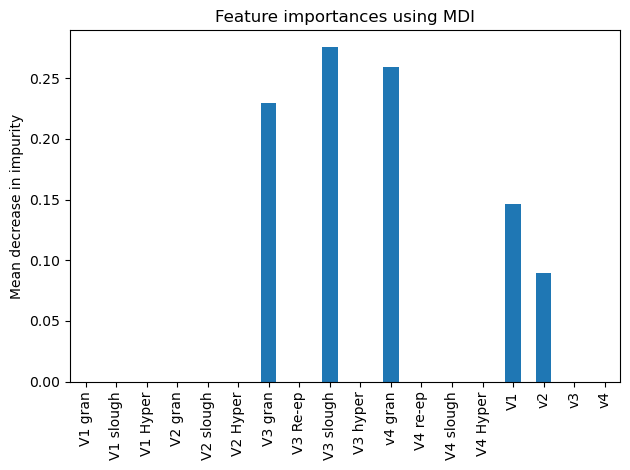

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier


Treatment=pd.read_csv("../dissertation/gran v1-4 data.csv")
Treatment_test=pd.read_csv("../dissertation/gran v1-4 data test.csv")
X_train=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
df_y_test=Treatment_test.iloc[:,0]


y_train = to_categorical(df_y)
y_test = to_categorical(df_y_test)



print(X_test)
print(y_test)


clf=DecisionTreeClassifier(max_depth=None,
                            class_weight="balanced",
                               criterion="log_loss",
                               ccp_alpha=0.04,
                  
    )

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 
print(y_pred)

print(classification_report(y_test,y_pred,output_dict=False,target_names=["non-healing","healing"]))

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
names=["V1 gran","V1 slough", "V1 Hyper", "V2 gran","V2 slough","V2 Hyper", "V3 gran", "V3 Re-ep","V3 slough","V3 hyper","v4 gran","V4 re-ep","V4 slough","V4 Hyper","V1","v2","v3","v4"]
tree.plot_tree(clf, filled = True,feature_names=names);
#plt.savefig('Tree', dpi=1200)
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)
fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

target = 'key'
class_names=["non-healing","healing"]


from supertree import SuperTree
st = SuperTree(
    clf, 
    X_test, 
    df_y, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree()
